[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlos-argueta/factor-graphs-from-scratch/blob/main/modules/02-gaussians-information-form/lesson.ipynb)

# Module 2 — Gaussians and the information form

> **Goal.** Make the **information (canonical) form** of a Gaussian a first-class object.
> Every Gaussian has two equally valid descriptions: a **moment** pair $(\mu,\Sigma)$ — a mean
> and a covariance — and an **information** pair $(\eta,\Lambda)$ — an information vector and an
> information (precision) matrix. M0 showed that a measurement *adds information*,
> $\Lambda \mathrel{+}= H^\top Q^{-1} H$, and that this is exactly what the reference
> `InformationFilter.update` does. This module explains *why* the whole rest of the course lives
> in the information form: **fusion is addition, conditional independence is a zero, and the two
> questions you ever ask of a joint Gaussian — _marginalise_ a variable out and _condition_ on a
> variable — are each trivial in exactly one of the two forms.** That asymmetry, and the
> **fill-in** it creates, is the seed of everything sparse solvers do.

$$\boxed{\ (\mu,\Sigma)\ \xleftrightarrow{\ \ \Lambda=\Sigma^{-1},\quad \eta=\Lambda\mu\ \ }\ (\eta,\Lambda)\ }$$

Two forms of the *same* distribution. The rest of the module is about what each one makes cheap.
By the end you will convert between them without thinking, and you will read an information matrix
$\Lambda$ as **a graph**: a nonzero block $\Lambda_{ij}$ is an edge between variables $i$ and $j$.

In [1]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `factorgraph`) importable.
# EDIT REPO_URL to point at your fork.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + factorgraph)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "gaussian_filters").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

## 1 · One Gaussian, two coordinate systems

A Gaussian over $x\in\mathbb{R}^n$ is

$$
p(x)\;\propto\;\exp\!\Big(-\tfrac12\,(x-\mu)^\top\,\Sigma^{-1}\,(x-\mu)\Big).
$$

The pair $(\mu,\Sigma)$ is the **moment form** — the one you meet first, the one a Kalman filter
carries. But the exponent is just a quadratic in $x$, and a quadratic can be written in more than
one way. Multiply it out (§2 does this carefully):

$$
-\tfrac12(x-\mu)^\top\Sigma^{-1}(x-\mu)
\;=\;
-\tfrac12\,x^\top \underbrace{\Sigma^{-1}}_{\Lambda}\,x
\;+\; x^\top\underbrace{\Sigma^{-1}\mu}_{\eta}
\;+\;\text{const}.
$$

The *same* density is now described by two other objects:

| | **moment form** | **information form** |
|---|---|---|
| parameters | mean $\mu$, covariance $\Sigma$ | info vector $\eta=\Sigma^{-1}\mu$, info matrix $\Lambda=\Sigma^{-1}$ |
| $\Lambda$ (a.k.a. precision) reads as | — | **certainty / curvature** of the cost |
| $\Sigma$ reads as | **shape of uncertainty** (the error ellipse) | — |
| recover the other | $\mu,\ \Sigma$ | $\mu=\Lambda^{-1}\eta,\quad \Sigma=\Lambda^{-1}$ |

Think of it physically. $\Sigma$ is the **width of the bell**: big $\Sigma$ means a wide, flat,
unsure distribution. $\Lambda=\Sigma^{-1}$ is the **steepness of the bowl**: big $\Lambda$ means
the negative-log cost rises sharply, i.e. you are very certain. They are inverses because being
*sure* (large $\Lambda$) is the same as being *narrow* (small $\Sigma$).

That negative-log cost is not a new object either — it is exactly the least-squares cost from
M0 and M1. Writing $C(x)=-\log p(x)$ up to a constant,

$$
C(x)=\tfrac12\,(x-\mu)^\top\Lambda\,(x-\mu),
\qquad
\nabla C = \Lambda(x-\mu),
\qquad
\nabla^2 C = \Lambda .
$$

**The information matrix is the Hessian of the cost.** M0 called it $J^\top J$; the
`InformationFilter` calls it `inf_matrix`; a factor graph calls it $\Lambda$. Same matrix.
The figure below shows the duality in 1-D: $\Sigma$ is the width of the bell on the left,
$\Lambda=1/\sigma^2$ is the steepness of the bowl on the right.

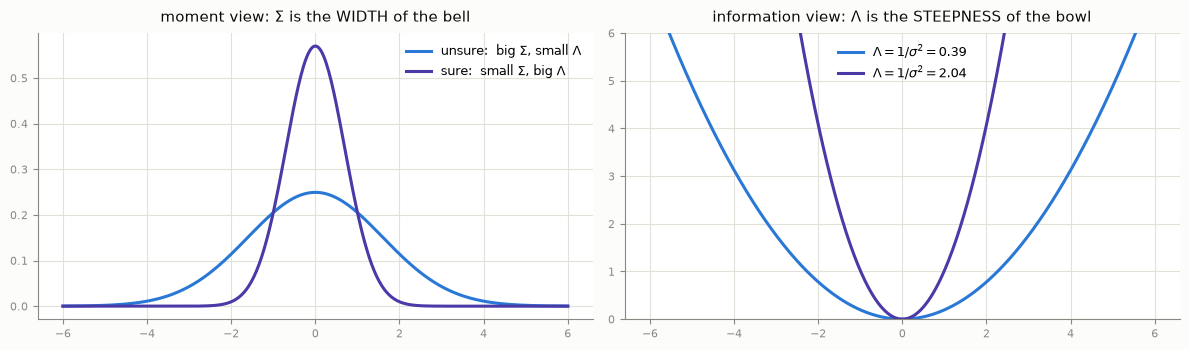

width and steepness are inverses:  Lambda = 1 / sigma^2
  sigma^2 = 2.560   ->   Lambda = 0.391
  sigma^2 = 0.490   ->   Lambda = 2.041


In [2]:
import matplotlib.pyplot as plt

# palette (light surface) + recessive chrome  — shared with M0/M1
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def _style(ax, title):
    ax.set_title(title, color=INK, fontsize=11, pad=8)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)

def gauss(x, mu, sig):
    return np.exp(-((x - mu) ** 2) / (2 * sig ** 2)) / (sig * np.sqrt(2 * np.pi))

# same Gaussian, two readouts: a sure one (narrow) and an unsure one (wide)
x = np.linspace(-6, 6, 400)
cases = [(1.6, BLUE, "unsure:  big $\\Sigma$, small $\\Lambda$"),
         (0.7, VIOLET, "sure:  small $\\Sigma$, big $\\Lambda$")]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), facecolor="#fcfcfb")
for sig, c, lab in cases:
    ax[0].plot(x, gauss(x, 0, sig), color=c, lw=2.2, label=lab)
    nll = (x ** 2) / (2 * sig ** 2)                 # -log density up to a const
    ax[1].plot(x, nll, color=c, lw=2.2, label=f"$\\Lambda=1/\\sigma^2={1/sig**2:.2f}$")
ax[0].legend(frameon=False, fontsize=9, loc="upper right")
ax[1].legend(frameon=False, fontsize=9, loc="upper center")
ax[1].set_ylim(0, 6)
_style(ax[0], r"moment view: $\Sigma$ is the WIDTH of the bell")
_style(ax[1], r"information view: $\Lambda$ is the STEEPNESS of the bowl")
fig.tight_layout(); plt.show()

print("width and steepness are inverses:  Lambda = 1 / sigma^2")
for sig, _, _ in cases:
    print(f"  sigma^2 = {sig**2:.3f}   ->   Lambda = {1/sig**2:.3f}")

## 2 · Reading the information form off the cost

### 2.1 · Completing the square

**The idea.** The information form is *defined* by insisting the cost has one fixed shape and
naming its two blocks:

$$
C(x)\;=\;\tfrac12\,x^\top\Lambda\,x\;-\;\eta^\top x\;+\;\text{const}.
\qquad(\star)
$$

By this definition $\Lambda$ is *whatever matrix sits in the quadratic term* and $\eta$ is
*whatever vector sits in the linear term* — with a **minus sign in front**, a convention whose
payoff shows up in two lines. To find $\Lambda$ and $\eta$ for a given Gaussian, expand its
moment-form cost and match it to the template $(\star)$ term by term.

Expand the exponent (full $n$-D algebra in **Appendix A**; $\Sigma^{-1}$ is symmetric, so the two
cross terms $x^\top\Sigma^{-1}\mu$ and $\mu^\top\Sigma^{-1}x$ are the same scalar and merge into one):

$$
\underbrace{\tfrac12(x-\mu)^\top\Sigma^{-1}(x-\mu)}_{\text{moment-form cost}}
=\tfrac12\,x^\top\Sigma^{-1}x
\;-\;\mu^\top\Sigma^{-1}\,x
\;+\;\tfrac12\,\mu^\top\Sigma^{-1}\mu .
$$

Now lay this beside the template $(\star)$ and match piece by piece — the two must agree for
**every** $x$, which forces the coefficients themselves to be equal:

$$
\begin{aligned}
\text{quadratic:}\quad & \tfrac12\,x^\top\Lambda\,x \;=\; \tfrac12\,x^\top\Sigma^{-1}x
  && \Rightarrow\quad \boxed{\;\Lambda=\Sigma^{-1}\;} \\[4pt]
\text{linear:}\quad & -\,\eta^\top x \;=\; -\,\mu^\top\Sigma^{-1}\,x
  && \Rightarrow\quad \eta^\top=\mu^\top\Sigma^{-1}\ \Rightarrow\ \boxed{\;\eta=\Sigma^{-1}\mu\;} .
\end{aligned}
$$

The **minus sign in the template is exactly why $\eta$ comes out $+\Sigma^{-1}\mu$**: the expanded
cost already carries a minus on its linear term ($-\mu^\top\Sigma^{-1}x$), and it cancels the
template's minus, leaving no stray sign. (Define the template with $+\eta^\top x$ instead and you'd
write $\eta=-\Sigma^{-1}\mu$ forever — the convention is picked precisely so $\eta=\Lambda\mu$ points
*toward* the mean, and so fusion in §2.3 is a clean addition.)

This is the same reading M0 did at the origin: the **information matrix is the quadratic
coefficient $J^\top J$**, and the **information vector is (minus) the gradient at $x=0$**,
$\eta=-\nabla C|_{0}=-\Lambda(0-\mu)=\Lambda\mu$. Nothing new — just a change of bookkeeping from
"where is the minimum and how wide is it" $(\mu,\Sigma)$ to "what is the curvature and which way
does it pull" $(\Lambda,\eta)$.

### 2.2 · What each piece *means*

- **$\Lambda$ (information / precision matrix)** — curvature of the cost, i.e. certainty. A large
  eigenvalue of $\Lambda$ is a direction you are very sure about (a steep, narrow valley). Zero
  information ($\Lambda=0$) is a flat cost: a perfectly uninformative "prior", which the moment
  form *cannot represent* because $\Sigma=\Lambda^{-1}$ blows up. The information form handles
  ignorance gracefully; the moment form does not.
- **$\eta$ (information vector)** — $\Lambda\mu$, "certainty $\times$ where". It is the direction
  and strength with which this Gaussian pulls the estimate. On its own $\eta$ is not the mean;
  you recover the mean only by dividing out the certainty, $\mu=\Lambda^{-1}\eta$.

### 2.3 · Fusion is addition — this is the whole point

Suppose you have two *independent* pieces of evidence about the same $x$ — a prior and a
measurement, or two sensor readings. "Fusing" them means asking what you believe once you account
for both. Three short steps take that from a product of bell curves to one line of arithmetic.

**1 — Combining independent evidence multiplies the densities.** This is the product rule you
already used in M0: when two observations are independent given $x$, their joint evidence
factorises, so the fused belief is proportional to the *product* of the two densities,

$$
p_{\text{fused}}(x)\ \propto\ p_1(x)\,p_2(x).
$$

**2 — Multiplying densities adds the negative-log costs.** Write each Gaussian in the exponential
form from §1, $p_i(x)\propto\exp(-C_i(x))$, where the cost $C_i=-\log p_i$ is the bowl from §1. A
product of exponentials *adds the exponents*:

$$
p_1(x)\,p_2(x)\ \propto\ \exp(-C_1)\,\exp(-C_2)\ =\ \exp\!\big(-(C_1+C_2)\big)
\quad\Longrightarrow\quad
C_{\text{fused}}(x)=C_1(x)+C_2(x).
$$

Taking the negative log turned the hard operation (a *product* of curves) into an easy one (a
*sum* of costs) — the same trade M0 and M1 made when they minimised a sum of squared residuals
instead of maximising a product of Gaussians.

**3 — Adding two costs adds their coefficients.** Each cost is already in the template shape
$(\star)$ from §2.1, so add them and collect powers of $x$:

$$
C_i(x)=\tfrac12\,x^\top\Lambda_i\,x-\eta_i^\top x+\text{const}_i
\quad\Longrightarrow\quad
C_{\text{fused}}(x)=\tfrac12\,x^\top(\Lambda_1+\Lambda_2)\,x-(\eta_1+\eta_2)^\top x+\text{const}.
$$

That sum is *itself* a quadratic of the template shape, so reading its coefficients off exactly as
in §2.1 gives the fused information parameters — just the sums:

$$
\boxed{\ \Lambda_{\text{fused}}=\Lambda_1+\Lambda_2,\qquad \eta_{\text{fused}}=\eta_1+\eta_2\ }.
$$

Two `+=` lines, no matrix inverse. Intuitively, each independent source contributes its own
**certainty** $\Lambda_i$ and its own **pull** $\eta_i$, and total certainty and total pull are the
running sums. **One trap:** this does *not* say the fused mean is $\mu_1+\mu_2$. Means don't add —
adding lives in $(\eta,\Lambda)$ space; you recover the fused mean by converting back,
$\mu_{\text{fused}}=\Lambda_{\text{fused}}^{-1}\eta_{\text{fused}}$, which works out to the
*precision-weighted average* of $\mu_1$ and $\mu_2$ (the sharper source pulls harder).

This additivity is *exactly* the reference `InformationFilter.update` below: a linear measurement
with model $C$ and noise $Q$ contributes information $C^\top Q^{-1} C$ and info vector
$C^\top Q^{-1} z$, and the filter just adds them on. Contrast the moment form, where fusing the
same two Gaussians needs the precision-weighted-mean formula and two inversions (we verify both
agree in §3).

In [3]:
import inspect
from gaussian_filters.inf import InformationFilter

print(inspect.getsource(InformationFilter.update))

	def update(self, z, dt):
		start_time = time.time()
		
		self.inf_matrix = self.inf_matrix + self.C().T @ self.Q_inv @ self.C()
		self.inf_vector = self.inf_vector + self.C().T @ self.Q_inv @ z

		end_time = time.time()
		execution_time = end_time - start_time
		self.exec_times_upd.append(execution_time)
		print(f"Execution time update: {execution_time} seconds")

		print("Average exec time update: ", sum(self.exec_times_upd) / len(self.exec_times_upd))
		
		return self.inf_vector, self.inf_matrix



## 3 · Convert freely, fuse by adding

Two tiny converters and a round-trip check, then we fuse two 2-D Gaussians **both ways** and
confirm the easy information-form addition equals the messy moment-form formula.

In [4]:
from numpy.linalg import inv

def to_information(mu, Sigma):
    Lam = inv(Sigma)
    return Lam @ mu, Lam            # eta, Lambda

def to_moment(eta, Lam):
    Sigma = inv(Lam)
    return Sigma @ eta, Sigma       # mu, Sigma

# --- a 2-D Gaussian, converted there and back ------------------------------
mu = np.array([1.0, -0.5])
Sigma = np.array([[2.0, 0.6],
                  [0.6, 0.8]])
eta, Lam = to_information(mu, Sigma)
mu_rt, Sig_rt = to_moment(eta, Lam)
assert np.allclose(mu_rt, mu) and np.allclose(Sig_rt, Sigma), "round-trip failed"
print("eta =", eta, "\nLambda =\n", Lam)
print("round-trip mu, Sigma recovered exactly:", np.allclose(mu_rt, mu) and np.allclose(Sig_rt, Sigma))

# --- fuse two Gaussians: information form (ADD) vs moment form (the formula)--
mu1, Sig1 = np.array([0.0, 0.0]), np.array([[1.5, 0.0], [0.0, 0.4]])
mu2, Sig2 = np.array([1.2, 0.8]), np.array([[0.5, -0.3], [-0.3, 1.2]])

# information form: just add
eta1, Lam1 = to_information(mu1, Sig1)
eta2, Lam2 = to_information(mu2, Sig2)
eta_f, Lam_f = eta1 + eta2, Lam1 + Lam2
mu_f, Sig_f = to_moment(eta_f, Lam_f)

# moment form: precision-weighted mean, two inverses
Sig_f_m = inv(inv(Sig1) + inv(Sig2))
mu_f_m = Sig_f_m @ (inv(Sig1) @ mu1 + inv(Sig2) @ mu2)

assert np.allclose(mu_f, mu_f_m) and np.allclose(Sig_f, Sig_f_m), "fusion mismatch"
print("\nfused mean (info-form add):   ", mu_f)
print("fused mean (moment formula):  ", mu_f_m, " -> identical")
print("fusion tightened covariance: det(Sig1)=%.3f det(Sig2)=%.3f -> det(fused)=%.3f"
      % (np.linalg.det(Sig1), np.linalg.det(Sig2), np.linalg.det(Sig_f)))

eta = [ 0.8871  -1.29032] 
Lambda =
 [[ 0.64516 -0.48387]
 [-0.48387  1.6129 ]]
round-trip mu, Sigma recovered exactly: True

fused mean (info-form add):    [1.0418  0.25209]
fused mean (moment formula):   [1.0418  0.25209]  -> identical
fusion tightened covariance: det(Sig1)=0.600 det(Sig2)=0.510 -> det(fused)=0.098


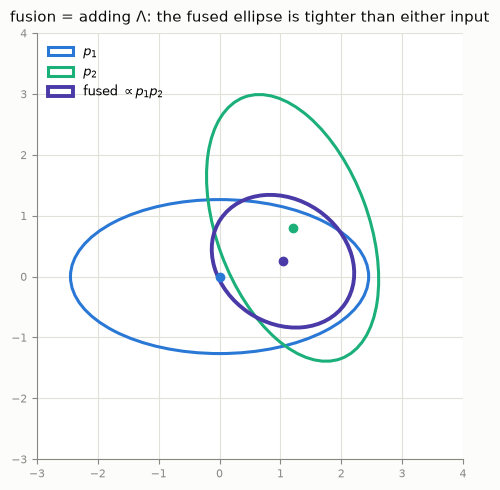

In [5]:
from matplotlib.patches import Ellipse

def cov_ellipse(ax, mu, Sigma, color, n_std=2.0, lw=2.2, ls="-", label=None):
    vals, vecs = np.linalg.eigh(Sigma)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(vals)
    e = Ellipse(mu, w, h, angle=angle, fill=False, lw=lw, ls=ls, color=color, label=label)
    ax.add_patch(e)
    return e

fig, ax = plt.subplots(figsize=(5.4, 5.0), facecolor="#fcfcfb")
cov_ellipse(ax, mu1, Sig1, BLUE, label="$p_1$")
cov_ellipse(ax, mu2, Sig2, AQUA, label="$p_2$")
cov_ellipse(ax, mu_f, Sig_f, VIOLET, lw=2.8, label="fused $\\propto p_1 p_2$")
for m, c in [(mu1, BLUE), (mu2, AQUA), (mu_f, VIOLET)]:
    ax.plot(*m, "o", color=c, ms=6)
ax.set_xlim(-3, 4); ax.set_ylim(-3, 4); ax.set_aspect("equal")
ax.legend(frameon=False, fontsize=9, loc="upper left")
_style(ax, r"fusion = adding $\Lambda$: the fused ellipse is tighter than either input")
fig.tight_layout(); plt.show()

## 4 · The two questions: marginalise vs condition

Partition the state into two groups, $x=(x_a,x_b)$. There are only two things you ever do to a
joint Gaussian, and they are opposites:

- **Marginalise $x_b$ out** — $p(x_a)=\int p(x_a,x_b)\,dx_b$. *"I no longer care about $x_b$;
  fold its uncertainty into what remains."* (Dropping an old robot pose you will never revisit.)
- **Condition on $x_b$** — $p(x_a\mid x_b=b_0)$. *"I now know $x_b$ exactly; what does that say
  about $x_a$?"* (A measurement pins a variable; how does the belief on its neighbours sharpen?)

**Write both forms in blocks.** Order the state as $x=(x_a,x_b)$ with $x_a\in\mathbb R^{n_a}$ and
$x_b\in\mathbb R^{n_b}$. Then cut every matrix into four blocks along the *same* $a\,|\,b$ split —
you literally slice out the rows and columns belonging to each group:

$$
\Sigma=\begin{bmatrix}\Sigma_{aa}&\Sigma_{ab}\\ \Sigma_{ba}&\Sigma_{bb}\end{bmatrix},
\qquad
\Lambda=\Sigma^{-1}=\begin{bmatrix}\Lambda_{aa}&\Lambda_{ab}\\ \Lambda_{ba}&\Lambda_{bb}\end{bmatrix}.
$$

- $\Sigma_{aa}$ ($n_a\times n_a$, rows and columns both from group $a$) — the covariance *among the
  $a$-variables*; it is exactly the covariance of $x_a$ on its own.
- $\Sigma_{bb}$ ($n_b\times n_b$) — likewise for the $b$-variables.
- $\Sigma_{ab}$ ($n_a\times n_b$, rows $a$, columns $b$) — the *cross-covariance*: how each
  $a$-variable co-varies with each $b$-variable. By symmetry $\Sigma_{ba}=\Sigma_{ab}^\top$.

$\Lambda$ is sliced the same way. **The one thing to watch:** $\Lambda_{aa}$ is the $aa$ block *of
the whole inverse* $\Sigma^{-1}$ — it is **not** $\Sigma_{aa}^{-1}$. Inverting mixes all four blocks
together, so $\Lambda_{aa}$ already "knows about" $b$. That mismatch between "block of the inverse"
and "inverse of the block" is the entire reason one direction below is a free read-off and the
other is a Schur complement. (In code the partition is just index-slicing: `Sigma[np.ix_(ia, ia)]`
is $\Sigma_{aa}$, `Sigma[np.ix_(ia, ib)]` is $\Sigma_{ab}$, and so on — see the next cell.)

**Marginalisation is trivial in the moment form.** The marginal of a Gaussian is just the
corresponding block of the mean and covariance — you *read it off* and throw the rest away:

$$
p(x_a):\qquad \mu_a^{\text{marg}}=\mu_a,\qquad \Sigma_a^{\text{marg}}=\Sigma_{aa}.
$$

In the information form the same operation costs a **Schur complement** (derived in Appendix B):

$$
\Lambda_a^{\text{marg}}=\Lambda_{aa}-\Lambda_{ab}\,\Lambda_{bb}^{-1}\,\Lambda_{ba}.
$$

That combination — *diagonal block $-$ (off-diagonal)(opposite diagonal block)$^{-1}$(off-diagonal)*
— has a name: it is the **Schur complement of $\Lambda_{bb}$ in $\Lambda$**, written
$\Lambda/\Lambda_{bb}$. It is exactly what one step of *block Gaussian elimination* (eliminating
$x_b$) always produces, which is where the formula comes from — Appendix B does the elimination.

**Conditioning is trivial in the information form.** Fixing $x_b=b_0$ just keeps the $aa$ block
of $\Lambda$ and shifts the information vector — no inverse:

$$
p(x_a\mid b_0):\qquad
\Lambda_{a\mid b}=\Lambda_{aa},\qquad
\eta_{a\mid b}=\eta_a-\Lambda_{ab}\,b_0 .
$$

In the moment form conditioning is the one that costs a Schur complement:

$$
\mu_{a\mid b}=\mu_a+\Sigma_{ab}\Sigma_{bb}^{-1}(b_0-\mu_b),
\qquad
\Sigma_{a\mid b}=\Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}.
$$

### The duality, on one slide

| operation | moment form $(\mu,\Sigma)$ | information form $(\eta,\Lambda)$ |
|---|---|---|
| **marginalise** $x_b$ out | **read off the block** $\Sigma_{aa},\mu_a$ | Schur complement on $\Lambda$ |
| **condition** on $x_b$ | Schur complement on $\Sigma$ | **read off the block** $\Lambda_{aa}$, shift $\eta$ |

**They are mirror images.** Read the table across: whatever is a *free slice* in one form is a
*Schur complement* in the other, and marginalise and condition trade places between the two forms.
So neither form wins outright — you keep both and, for each operation, work in the one where it is
a plain read-off.

What carries forward is the recurring cost. Both Schur complements have the *same* shape —
$(\text{block})-(\text{off-diag})(\text{block})^{-1}(\text{off-diag})$ — and that shape **is** one
step of Gaussian elimination: removing a variable from the system by folding its effect into the
ones that remain. So **marginalising a variable out is eliminating it** — the very operation a
sparse solver runs when it factorises the system, and an incremental smoother runs when it retires
an old state. §5 shows what that elimination does to the *graph*: it creates **fill-in**, new edges
between the eliminated variable's former neighbours. M5 turns the same operation into the full
incremental machinery.

In [6]:
# --- one joint Gaussian, both operations verified both ways ----------------
rng = np.random.default_rng(0)
M = rng.normal(size=(3, 3))
Sigma = M @ M.T + 0.5 * np.eye(3)         # a valid SPD covariance
mu = np.array([1.0, -2.0, 0.5])
Lam = inv(Sigma)
eta = Lam @ mu

ia, ib = [0, 1], [2]                       # keep a = (x0, x1), touch b = x2
ix = np.ix_
Saa, Sab, Sbb = Sigma[ix(ia, ia)], Sigma[ix(ia, ib)], Sigma[ix(ib, ib)]
Laa, Lab, Lbb = Lam[ix(ia, ia)], Lam[ix(ia, ib)], Lam[ix(ib, ib)]

# ---- MARGINALISE x_b out : trivial in moment form, Schur in info form -----
Sig_marg = Saa                                             # moment: just the block
Lam_marg = Laa - Lab @ inv(Lbb) @ Lam[ix(ib, ia)]          # info: Schur complement
assert np.allclose(inv(Lam_marg), Sig_marg), "marginal covariance mismatch"
print("MARGINALISE x2 out:")
print("  moment (read off Sigma_aa)   :\n", Sig_marg)
print("  info   (Schur, then invert)  :\n", inv(Lam_marg))
print("  identical:", np.allclose(inv(Lam_marg), Sig_marg))

# ---- CONDITION on x_b = b0 : trivial in info form, Schur in moment form ----
b0 = np.array([0.3])
Lam_cond = Laa                                             # info: just the block
eta_cond = eta[ia] - Lab @ b0                              # info: shift
mu_cond = inv(Lam_cond) @ eta_cond
Sig_cond_m = Saa - Sab @ inv(Sbb) @ Sigma[ix(ib, ia)]      # moment: Schur complement
mu_cond_m = mu[ia] + Sab @ inv(Sbb) @ (b0 - mu[ib])
assert np.allclose(mu_cond, mu_cond_m), "conditional mean mismatch"
assert np.allclose(inv(Lam_cond), Sig_cond_m), "conditional covariance mismatch"
print("\nCONDITION on x2 = 0.3:")
print("  info   (read off Lambda_aa, shift eta) -> mu =", mu_cond)
print("  moment (Schur complement)              -> mu =", mu_cond_m)
print("  identical:", np.allclose(mu_cond, mu_cond_m) and np.allclose(inv(Lam_cond), Sig_cond_m))

MARGINALISE x2 out:
  moment (read off Sigma_aa)   :
 [[0.9434  0.31553]
 [0.31553 0.9287 ]]
  info   (Schur, then invert)  :
 [[0.9434  0.31553]
 [0.31553 0.9287 ]]
  identical: True

CONDITION on x2 = 0.3:
  info   (read off Lambda_aa, shift eta) -> mu = [ 1.02293 -1.96521]
  moment (Schur complement)              -> mu = [ 1.02293 -1.96521]
  identical: True


## 5 · Sparsity: the information matrix *is* the graph

Here is the fact that turns Gaussians into factor graphs. In the information matrix,

$$
\boxed{\ \Lambda_{ij}=0 \iff x_i \text{ and } x_j \text{ are conditionally independent given all other variables.}\ }
$$

A **zero block in $\Lambda$ is a missing edge.** (Appendix C proves it: $\Lambda_{ij}$ is the
coefficient of the cross term $x_i^\top(\cdot)x_j$ in the cost, and no cross term means the two
variables only interact *through* the others.) Note this is **not** the same as $\Sigma_{ij}=0$:
covariance-zero is *marginal* independence, a much rarer thing. In a chain of robot poses every
pair is correlated ($\Sigma$ is dense), yet each pose talks *directly* only to its neighbours, so
$\Lambda$ is tridiagonal. **$\Sigma$ dense, $\Lambda$ sparse** is the normal state of affairs, and
it is why estimators are built on $\Lambda$.

A factor graph makes this literal: each **factor** touching a set of variables $\{i,j,\dots\}$
adds its block *only* into those rows and columns of $\Lambda$. Variables that never share a
factor keep a zero block. Assemble all the factors and you get a sparse $\Lambda$ whose nonzero
pattern is the graph's adjacency — exactly the additive picture from M0 ("each factor contributes
a block to $\Lambda$; you sum them").

### Marginalisation creates fill-in

Now combine §4 and this section. Marginalising a variable out is a Schur complement, and the term
$\Lambda_{ab}\Lambda_{bb}^{-1}\Lambda_{ba}$ writes into **every (neighbour, neighbour) entry** of
the eliminated variable. So dropping a node **connects all of its former neighbours to each
other** — new edges appear that were not in the original graph. This is **fill-in**.

The demo below builds a chain $1\!-\!2\!-\!3\!-\!4\!-\!5$ (tridiagonal $\Lambda$), marginalises out
the middle node $3$, and shows a brand-new edge $2\!-\!4$: the two neighbours of $3$ are now
directly coupled. **Conditioning**, by contrast, just deletes the row and column — no fill-in —
which is why "fixing" a variable is cheap and "forgetting" one is not. Both operations come back in
the solver: eliminating a variable produces a *marginal* on the rest (the Schur complement we just
watched) and a *conditional* for the variable itself, and §6 sketches how the two fit together.

This single tension — keep old variables (sparse but the graph grows without bound) versus
marginalise them away (bounded size but the graph fills in and densifies) — is the whole design
space of incremental and fixed-lag smoothing, and the reason a good **elimination order** matters (Appendix D).
M5 builds the machinery; here we just watch the fill-in appear.

In [7]:
# chain 1-2-3-4-5 : each node couples only to its neighbours -> tridiagonal Lambda
n = 5
Lam = np.zeros((n, n))
for i in range(n):
    Lam[i, i] = 2.0
for i in range(n - 1):
    Lam[i, i + 1] = Lam[i + 1, i] = -0.7

# marginalise out the middle node (index 2 == "node 3")
keep, drop = [0, 1, 3, 4], [2]
ix = np.ix_
Lkk = Lam[ix(keep, keep)]
Lkd = Lam[ix(keep, drop)]
Ldd = Lam[ix(drop, drop)]
Lam_marg = Lkk - Lkd @ inv(Ldd) @ Lam[ix(drop, keep)]

# in 'keep' coordinates, old node 2 -> row/col 1, old node 4 -> row/col 2
edge_before = Lam[1, 3]          # nodes 2 and 4 in the original chain: not neighbours
edge_after = Lam_marg[1, 2]      # nodes 2 and 4 after eliminating node 3
print("chain Lambda (tridiagonal):\n", Lam)
print("\nafter marginalising node 3:\n", np.round(Lam_marg, 4))
print(f"\nedge 2-4 before elimination: {edge_before:+.3f}   (zero: not connected)")
print(f"edge 2-4 after  elimination: {edge_after:+.3f}   (nonzero: FILL-IN)")
assert edge_before == 0.0 and edge_after != 0.0

chain Lambda (tridiagonal):
 [[ 2.  -0.7  0.   0.   0. ]
 [-0.7  2.  -0.7  0.   0. ]
 [ 0.  -0.7  2.  -0.7  0. ]
 [ 0.   0.  -0.7  2.  -0.7]
 [ 0.   0.   0.  -0.7  2. ]]

after marginalising node 3:
 [[ 2.    -0.7    0.     0.   ]
 [-0.7    1.755 -0.245  0.   ]
 [ 0.    -0.245  1.755 -0.7  ]
 [ 0.     0.    -0.7    2.   ]]

edge 2-4 before elimination: +0.000   (zero: not connected)
edge 2-4 after  elimination: -0.245   (nonzero: FILL-IN)


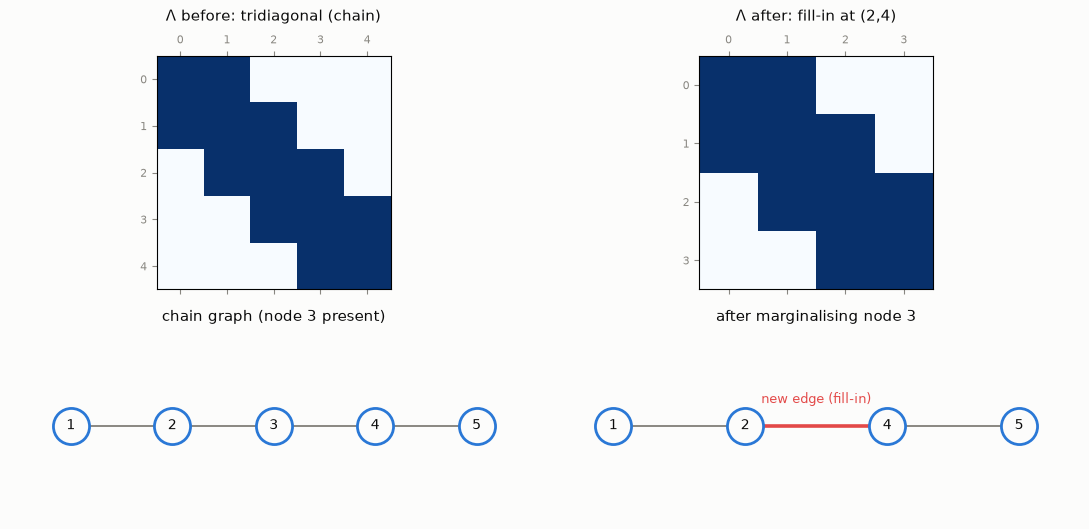

In [8]:
# visualise: sparsity pattern (top) and the graph (bottom), before vs after
def draw_graph(ax, adj, labels, pos, title, new_edges=()):
    for (i, j) in [(i, j) for i in range(len(labels)) for j in range(i + 1, len(labels))]:
        if adj[i, j] != 0:
            c = RED if (i, j) in new_edges or (j, i) in new_edges else MUTED
            lw = 2.6 if c == RED else 1.4
            ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], color=c, lw=lw, zorder=1)
    for k, lab in enumerate(labels):
        ax.plot(*pos[k], "o", ms=26, color="#fcfcfb", markeredgecolor=BLUE, mew=2, zorder=2)
        ax.text(*pos[k], lab, ha="center", va="center", color=INK, fontsize=10, zorder=3)
    ax.set_title(title, color=INK, fontsize=11, pad=8)
    ax.set_xlim(-0.6, len(labels) - 0.4); ax.set_ylim(-1.1, 1.1); ax.axis("off")

fig, ax = plt.subplots(2, 2, figsize=(11, 5.4), facecolor="#fcfcfb",
                       gridspec_kw={"height_ratios": [1.25, 1]})
for a, (Mtx, ttl) in zip(ax[0], [(Lam, r"$\Lambda$ before: tridiagonal (chain)"),
                                 (Lam_marg, r"$\Lambda$ after: fill-in at (2,4)")]):
    im = a.matshow(np.abs(Mtx) > 1e-9, cmap="Blues", vmin=0, vmax=1)
    a.set_title(ttl, color=INK, fontsize=11, pad=10)
    a.tick_params(colors=MUTED, labelsize=8)

pos5 = {i: (i, 0.0) for i in range(5)}
draw_graph(ax[1][0], Lam, ["1", "2", "3", "4", "5"], pos5, "chain graph (node 3 present)")
# after: keep nodes 1,2,4,5 laid out, with the new 2-4 edge in red
Lam_full = np.zeros((5, 5)); keep_idx = [0, 1, 3, 4]
for a_, i in enumerate(keep_idx):
    for b_, j in enumerate(keep_idx):
        Lam_full[i, j] = Lam_marg[a_, b_]
pos4 = {0: (0, 0), 1: (1.3, 0), 3: (2.7, 0), 4: (4.0, 0)}
axg = ax[1][1]
for (i, j) in [(0, 1), (1, 3), (3, 4)]:
    axg.plot([pos4[i][0], pos4[j][0]], [0, 0], color=MUTED, lw=1.4, zorder=1)
axg.plot([pos4[1][0], pos4[3][0]], [0, 0], color=RED, lw=2.6, zorder=1)  # fill-in 2-4
axg.annotate("new edge (fill-in)", (0.5 * (pos4[1][0] + pos4[3][0]), 0),
             color=RED, fontsize=9, ha="center", va="bottom",
             xytext=(0, 14), textcoords="offset points")
for i in keep_idx:
    axg.plot(*pos4[i], "o", ms=26, color="#fcfcfb", markeredgecolor=BLUE, mew=2, zorder=2)
    axg.text(*pos4[i], str(i + 1), ha="center", va="center", color=INK, fontsize=10, zorder=3)
axg.set_title("after marginalising node 3", color=INK, fontsize=11, pad=8)
axg.set_xlim(-0.6, 4.6); axg.set_ylim(-1.1, 1.1); axg.axis("off")
fig.tight_layout(); plt.show()

## 6 · Tie-back and takeaways

- A Gaussian has **two coordinate systems**: moment $(\mu,\Sigma)$ and information $(\eta,\Lambda)$,
  related by $\Lambda=\Sigma^{-1},\ \eta=\Lambda\mu$. $\Sigma$ is the width of the bell; $\Lambda$
  is the steepness of the bowl and the **Hessian of the least-squares cost** from M0/M1.
- **Fusion is addition** in the information form: $\Lambda=\sum_i\Lambda_i,\ \eta=\sum_i\eta_i$.
  That is why the reference `InformationFilter.update` is two `+=` lines and why factor graphs are
  built additively.
- The two operations on a joint Gaussian are **mirror images**: marginalising is a free slice in
  moment form and a Schur complement in information form; conditioning is the reverse. Neither form
  is "better" — you keep both and use whichever makes the current operation cheap.
- **$\Lambda_{ij}=0$ is a missing graph edge** (conditional independence), and $\Sigma$ being dense
  does not stop $\Lambda$ from being sparse. **Marginalising a variable causes fill-in**; conditioning
  does not.

**Where this leads.** M3 assembles $\Lambda$ (and $\eta$) directly from factors and solves the sparse
linear system — the batch optimiser. That solve uses both operations from §4: eliminating a variable
produces a **marginal** on the rest (the Schur complement, with its fill-in) and a **conditional**
$p(x_{\text{elim}}\mid\text{rest})$, a row of the triangular factor. Marginalisation sets the
sparsity and the elimination order; conditioning is the factorisation you then back-substitute
through to recover the estimate — the $\eta_{a\mid b}=\eta_a-\Lambda_{ab}b_0$ shift from §4, applied
variable by variable. M5 makes both operations *incremental*, so a solver can update the
factorisation in place — retiring old variables or folding in out-of-order measurements without
redoing everything from scratch. From here on every estimator we build lives in the information form;
this module is the vocabulary for all of it.

## Appendix

### A · Completing the square in $n$ dimensions

Start from the moment-form exponent and expand, using $\Sigma^{-1}=\Lambda$ symmetric:

$$
\tfrac12(x-\mu)^\top\Lambda(x-\mu)
=\tfrac12 x^\top\Lambda x-\tfrac12 x^\top\Lambda\mu-\tfrac12\mu^\top\Lambda x+\tfrac12\mu^\top\Lambda\mu.
$$

Because $\Lambda=\Lambda^\top$, the two cross terms are equal scalars,
$x^\top\Lambda\mu=\mu^\top\Lambda x$, so they combine:

$$
=\tfrac12 x^\top\Lambda x-\mu^\top\Lambda\,x+\tfrac12\mu^\top\Lambda\mu
=\tfrac12 x^\top\Lambda x-\eta^\top x+\text{const},\qquad \eta:=\Lambda\mu .
$$

Going the other way — from an information-form cost $\tfrac12 x^\top\Lambda x-\eta^\top x$ back to a
mean — is literally *completing the square*: factor out $\Lambda$,

$$
\tfrac12\big(x-\Lambda^{-1}\eta\big)^\top\Lambda\big(x-\Lambda^{-1}\eta\big)-\tfrac12\eta^\top\Lambda^{-1}\eta,
$$

so the minimiser (the mean) is $\mu=\Lambda^{-1}\eta$ and the leftover constant
$-\tfrac12\eta^\top\Lambda^{-1}\eta$ is the log-normaliser. Solving $\Lambda\mu=\eta$ for $\mu$ is
exactly what "recover the mean from the information form" means — and, not coincidentally, exactly
the normal-equation solve at the end of every Gauss–Newton step.

### B · The Schur complement, from block Gaussian elimination

Both Schur complements in §4 come from one identity. Block-factor $\Lambda$ (eliminate the
$b$-block by row reduction):

$$
\Lambda=\begin{bmatrix}\Lambda_{aa}&\Lambda_{ab}\\ \Lambda_{ba}&\Lambda_{bb}\end{bmatrix}
=\begin{bmatrix}I&\Lambda_{ab}\Lambda_{bb}^{-1}\\ 0&I\end{bmatrix}
\begin{bmatrix}\,S&0\,\\ 0&\Lambda_{bb}\end{bmatrix}
\begin{bmatrix}I&0\\ \Lambda_{bb}^{-1}\Lambda_{ba}&I\end{bmatrix},
\qquad
S=\Lambda_{aa}-\Lambda_{ab}\Lambda_{bb}^{-1}\Lambda_{ba}.
$$

$S$ is the **Schur complement** of $\Lambda_{bb}$. Two consequences:

1. **Marginalisation.** Integrating $x_b$ out of the Gaussian integrates the middle block's
   $b$-part, leaving the $a$-cost governed by $S$. So the marginal information matrix is
   $\Lambda_a^{\text{marg}}=S=\Lambda_{aa}-\Lambda_{ab}\Lambda_{bb}^{-1}\Lambda_{ba}$ — precisely
   §4's formula. (Equivalently: $\big(\Sigma_{aa}\big)^{-1}=S$, the block-inverse identity, which
   is why $\Sigma_{aa}$ is a free read-off but its *inverse* is not.)
2. **Conditioning.** Fixing $x_b=b_0$ freezes the $b$-block; the remaining cost in $x_a$ keeps
   curvature $\Lambda_{aa}$ (no Schur term at all), with a linear shift $-\Lambda_{ab}b_0$. The
   Schur complement instead appears when you write the *moment-form* conditional covariance,
   $\Sigma_{a\mid b}=\Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}$ — the same identity applied
   to $\Sigma$.

The mirror symmetry of §4 is just this one factorisation applied to $\Lambda$ (marginalise) or to
$\Sigma$ (condition).

### C · Why $\Lambda_{ij}=0$ means conditional independence

Write the joint cost and pull out the terms containing $x_i$ and $x_j$:

$$
C(x)=\tfrac12\sum_{k,l}x_k^\top\Lambda_{kl}x_l-\sum_k\eta_k^\top x_k .
$$

The *only* place $x_i$ and $x_j$ appear multiplied together is the pair of cross terms
$x_i^\top\Lambda_{ij}x_j$ (and its transpose). If $\Lambda_{ij}=0$, the cost — hence the density —
factors as $p(x)=f(x_i,\text{rest})\,g(x_j,\text{rest})$ with no direct $x_i\!-\!x_j$ coupling,
which is the definition of conditional independence given the remaining variables. Conversely a
nonzero $\Lambda_{ij}$ is a direct interaction, i.e. an edge. Marginal independence
($\Sigma_{ij}=0$) is a different and stronger statement, because $\Sigma=\Lambda^{-1}$ mixes all
the blocks together — which is exactly why a sparse $\Lambda$ routinely has a dense $\Sigma$.

### D · The elimination game: fill-in and ordering

Marginalising a variable is one step of the elimination in Appendix B, and the Schur term
$\Lambda_{ab}\Lambda_{bb}^{-1}\Lambda_{ba}$ is an **outer product over the eliminated variable's
neighbours**: it deposits a nonzero into every (neighbour, neighbour) block. Graph-theoretically,
eliminating a node **adds an edge between every pair of its neighbours** — the eliminated node's
neighbourhood becomes a clique. That is the fill-in of §5.

The amount of fill-in depends on the **order** you eliminate in: remove a low-degree node (few
neighbours) and you add few edges; remove a hub and you densify the whole graph. Finding an order
that minimises fill-in is NP-hard in general, but cheap heuristics (minimum-degree, nested
dissection) get most of the way — and choosing a good order is what makes incremental
solving fast. M5 builds this out; for now the takeaway is that **the sparsity you
worked to keep in $\Lambda$ is a resource that marginalisation spends.**